In [17]:
import os, sys, numpy
import cooling
import cirq_google
import matplotlib.pyplot as plt

The first level of the cooling package is given by the "<span style="color:blue">CoolingDevice</span>
" and "<span style="color:blue">Lattice</span>" objects. The CoolingDevice specifies the system and bath qubits and their connectivity. It can be initialised from either a pre-build cirq Device, in which case it inherits the Device geometry (but the user must specify which qubits belong to the "system" and to the "bath"); or it can be initialised from a Lattice object. 

The Lattice is a user-build structure handling the system qubit geometry and connectivity. Several pre-built lattices can be found in the lattice folder, for example ChainLattice1D and SquareLattice2D. A new lattice (e.g. Kagome) should be easy to add following the examples in that folder. If CoolingDevice is created from a cirq Device, the lattice is a GraphLattice which inherits the Device graph geometry. 

The lattice provides a method, <span style="color:red">bond_colouring</span>, which partitions bonds into disjoint sets (i.e. commuting bonds) which will be used later for evolution. The CoolingDevice can be visualised via the <span style="color:red">draw</span> method. Below are examples setting up the CoolingDevice for a 6x6 square lattice with periodic boundaries, and Google's 54 qubit Sycamore device.

Text(0.5, 1.0, 'Sycamore device')

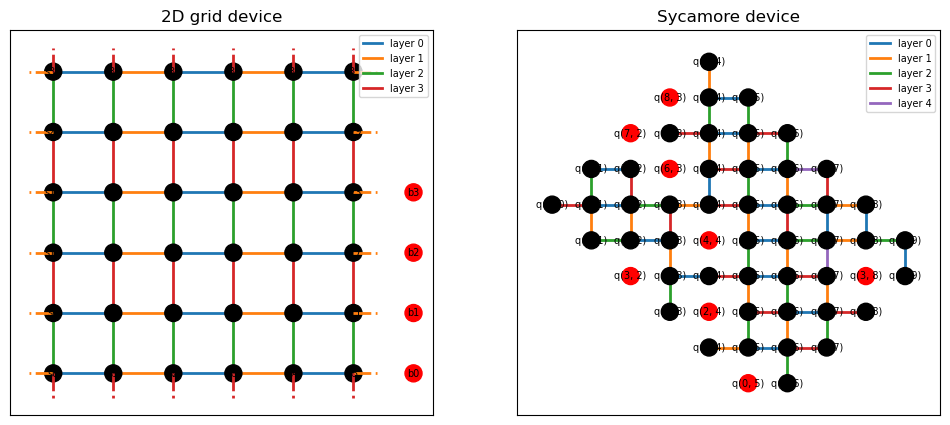

In [24]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,5))

# 2D lattice (6x6, PBC) with 4 bath qubits

Lx = 6
Ly = 6
pbc_x = True
pbc_y = True

lattice = cooling.SquareLattice2D(Lx, Ly, pbc_x=pbc_x, pbc_y=pbc_y)  ### setup the lattice
device = cooling.CoolingDevice.from_lattice(lattice, Nb=4)  ### initialise the CoolingDevice from lattice
device.draw(ax=ax1) # visualise the device
ax1.set_title("2D grid device")

google_device = cirq_google.Sycamore  # 54-qubit Sycamore
qs = sorted(google_device.metadata.qubit_set)
bath_qubits   = [qs[0], qs[7], qs[12], qs[18], qs[23], qs[40], qs[45], qs[50]]
system_qubits = [q for q in qs if q not in bath_qubits] 

device = cooling.CoolingDevice.from_cirq_device(google_device, system_qubits, bath_qubits) ### initialise from Device
device.draw(ax2)  # visualise the device
ax2.set_title("Sycamore device")
